# GPU STOMP with STUMPY

This notebook is a thesis-ready starting point for running a GPU-accelerated matrix profile on the processed BTCUSDT 1-minute dataset.

It keeps the same project-relative path pattern as the existing CPU notebook, but swaps the main compute step to `stumpy.gpu_stump` when CUDA is available.

In [1]:
from numba import cuda

print("CUDA available:", cuda.is_available())

if cuda.is_available():
    device = cuda.get_current_device()
    print("GPU:", device.name)
else:
    print("No CUDA GPU detected")

CUDA available: True
GPU: b'NVIDIA GeForce RTX 3060 Laptop GPU'


In [2]:
# Check CUDA visibility and run a basic GPU matrix calculation (A + B = C)

import numpy as np


if not cuda.is_available():
    print("CUDA accessible: False")
else:
    gpu_name = device.name.decode() if isinstance(device.name, bytes) else str(device.name)
    print("CUDA accessible: True")
    print(f"Active GPU: {gpu_name}")

    @cuda.jit
    def mat_add(a, b, c):
        i, j = cuda.grid(2)
        if i < c.shape[0] and j < c.shape[1]:
            c[i, j] = a[i, j] + b[i, j]

    # Small test matrices
    A = np.arange(16, dtype=np.float32).reshape(4, 4)
    B = np.ones((4, 4), dtype=np.float32) * 2
    C = np.zeros((4, 4), dtype=np.float32)

    # Move to GPU
    dA = cuda.to_device(A)
    dB = cuda.to_device(B)
    dC = cuda.to_device(C)

    # Launch kernel
    threads_per_block = (16, 16)
    blocks_per_grid_x = (C.shape[0] + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_per_grid_y = (C.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]
    mat_add[(blocks_per_grid_x, blocks_per_grid_y), threads_per_block](dA, dB, dC)

    # Copy result back
    C_result = dC.copy_to_host()

    print("A:\n", A)
    print("B:\n", B)
    print("C (GPU result):\n", C_result)
    print("Result correct:", np.allclose(C_result, A + B))

CUDA accessible: True
Active GPU: NVIDIA GeForce RTX 3060 Laptop GPU


c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\.thesis-env\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


A:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]
B:
 [[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]
C (GPU result):
 [[ 2.  3.  4.  5.]
 [ 6.  7.  8.  9.]
 [10. 11. 12. 13.]
 [14. 15. 16. 17.]]
Result correct: True


## 1. Setup

If needed, install the repository dependencies from the project root:

```bash
pip install -r requirements.txt
```

For GPU execution, the Python environment also needs a working CUDA-capable setup that `numba.cuda` can detect.

In [3]:
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy

plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
# Resolve paths relative to this notebook location.
project_root = Path("../../").resolve()
data_path = project_root / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"Processed dataset was not found at: {data_path}")

data_path

WindowsPath('C:/Users/learn/OneDrive/Desktop/Masters Thesis/MastersThesis/data/processed/crypto/1min/BTCUSDT_1m_processed.parquet')

## 2. Load the processed BTCUSDT data

In [5]:
df = pd.read_parquet(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Rows: 4,502,648
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']
Date range: 2017-08-17 04:00:00+00:00 -> 2026-03-15 23:59:00+00:00


## 3. Select a signal and one-year analysis window

`log_return` is a sensible first univariate signal for matrix profiling because it reduces long-run price trend dominance.

This notebook is configured to run on a full calendar year so the GPU path is used for a genuinely large experiment rather than a short debug sample.

In [6]:
import numpy as np
import pandas as pd

candidate_column = "log_return"
analysis_year = 2025
year_start = pd.Timestamp(f"{analysis_year}-01-01 00:00:00", tz="UTC")
year_end = pd.Timestamp(f"{analysis_year + 1}-01-01 00:00:00", tz="UTC")

if candidate_column not in df.columns:
    raise KeyError(f"Expected column '{candidate_column}' was not found.")

sample_df = (
    df[["timestamp", "open", "high", "low", "close", "volume", candidate_column]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("timestamp")
    .reset_index(drop=True)
    .rename(columns={candidate_column: "signal"})
)

sample_df = sample_df.loc[
    (sample_df["timestamp"] >= year_start) & (sample_df["timestamp"] < year_end)
].reset_index(drop=True).copy()

if sample_df.empty:
    raise ValueError(
        f"No rows were found for analysis_year={analysis_year}. "
        "Check the dataset coverage before running the GPU profile."
    )

signal = sample_df["signal"].to_numpy(dtype=np.float64)

print(f"Analysis rows used in this notebook: {len(sample_df):,}")
print(f"Analysis date range: {sample_df['timestamp'].min()} -> {sample_df['timestamp'].max()}")
print("Columns in sample_df:", sample_df.columns.tolist())

Analysis rows used in this notebook: 525,600
Analysis date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00
Columns in sample_df: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'signal']


In [7]:
print(f"Sample date range: {sample_df['timestamp'].min()} -> {sample_df['timestamp'].max()}")

Sample date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00


## 4. Check GPU availability

If CUDA is visible to `numba`, the notebook will use `stumpy.gpu_stump`. Otherwise it falls back to `stumpy.stump` so you can still edit and validate the rest of the workflow.

In [8]:
gpu_available = False
gpu_error = None
gpu_name = None
gpu_total_memory_gb = None

try:
    from numba import cuda

    gpu_available = cuda.is_available()
    if gpu_available:
        device = cuda.get_current_device()
        gpu_name = device.name.decode() if isinstance(device.name, bytes) else device.name
        gpu_total_memory_gb = device.total_memory / (1024 ** 3)
except Exception as exc:
    gpu_error = repr(exc)

print(f"GPU available: {gpu_available}")
if gpu_name is not None:
    print(f"GPU name: {gpu_name}")
if gpu_total_memory_gb is not None:
    print(f"GPU memory (GB): {gpu_total_memory_gb:.2f}")
if gpu_error is not None:
    print(f"GPU probe error: {gpu_error}")

GPU available: True
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
GPU probe error: AttributeError('total_memory')


## 5. Run GPU STOMP

The `window` value is in minutes here because the dataset is 1-minute data. Adjust it to the motif duration you want to test.

In [9]:
window = 60
device_id = 0

if len(signal) <= window:
    raise ValueError("Signal length must be greater than the subsequence window.")

start = perf_counter()

if gpu_available:
    backend = "stumpy.gpu_stump"
    mp = stumpy.gpu_stump(signal, m=window, device_id=device_id)
else:
    backend = "stumpy.stump"
    warnings.warn(
        "CUDA GPU not available. Falling back to CPU STUMP so the notebook remains editable.",
        stacklevel=2,
    )
    mp = stumpy.stump(signal, m=window)

elapsed_seconds = perf_counter() - start

matrix_profile = np.asarray(mp[:, 0], dtype=np.float64)
nearest_neighbor_idx = np.asarray(mp[:, 1], dtype=np.int64)

print(f"Backend used: {backend}")
print(f"Window size: {window}")
print(f"Profile length: {len(matrix_profile):,}")
print(f"Elapsed seconds: {elapsed_seconds:,.2f}")

Backend used: stumpy.gpu_stump
Window size: 60
Profile length: 525,541
Elapsed seconds: 93.69


## 6. Inspect the matrix profile

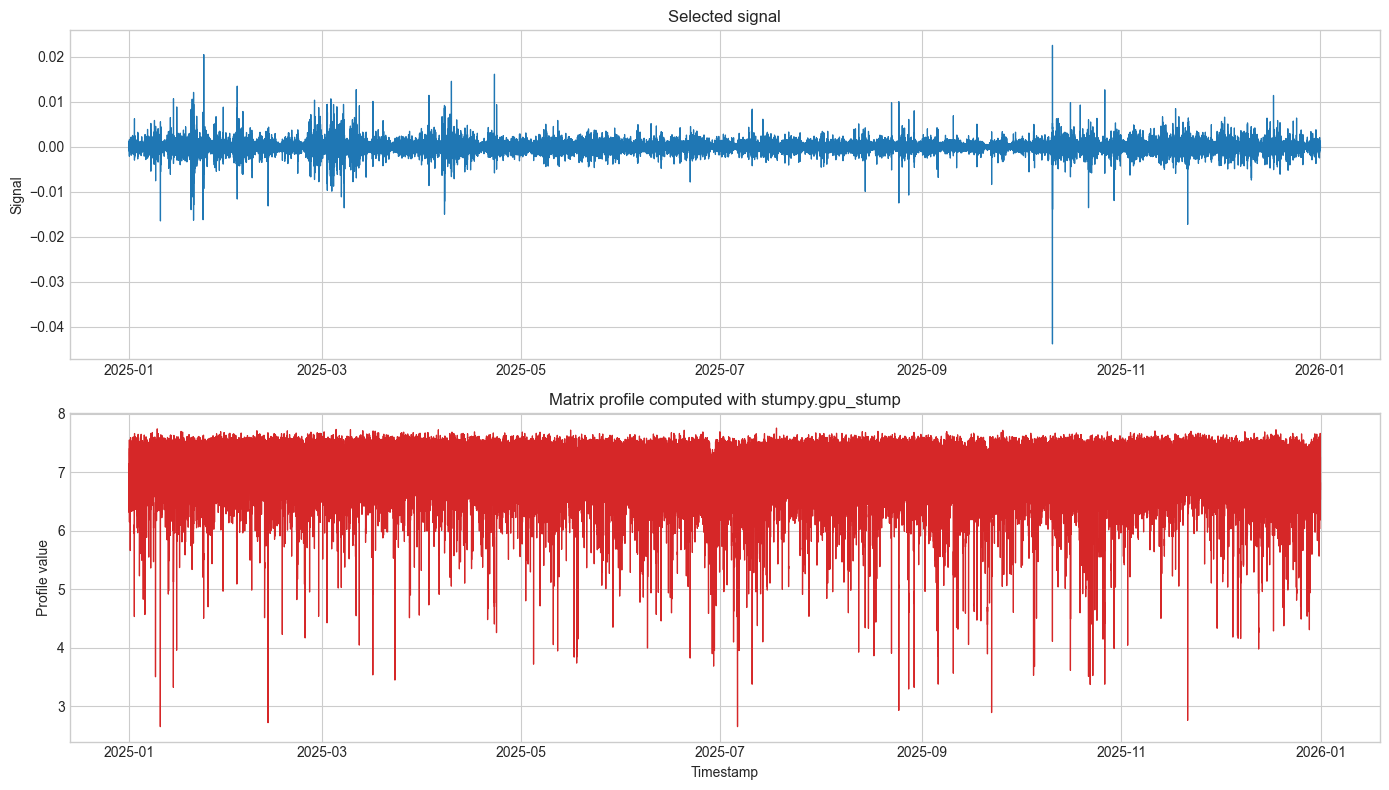

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(sample_df["timestamp"], sample_df["signal"], color="tab:blue", linewidth=0.9)
axes[0].set_title("Selected signal")
axes[0].set_ylabel("Signal")

profile_timestamps = sample_df["timestamp"].iloc[: len(matrix_profile)]
axes[1].plot(profile_timestamps, matrix_profile, color="tab:red", linewidth=0.9)
axes[1].set_title(f"Matrix profile computed with {backend}")
axes[1].set_ylabel("Profile value")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## 7. Extract top motifs and discords

In [11]:
def _overlaps(index_a: int, index_b: int, subseq_window: int) -> bool:
    return abs(index_a - index_b) < subseq_window


def top_non_overlapping_motifs(profile, neighbor_idx, subseq_window, k=5):
    motifs = []
    order = np.argsort(profile)

    for idx in order:
        if not np.isfinite(profile[idx]):
            continue

        nn_idx = int(neighbor_idx[idx])
        if nn_idx < 0:
            continue

        conflict = False
        for existing in motifs:
            if _overlaps(idx, existing["query_index"], subseq_window):
                conflict = True
                break
            if _overlaps(idx, existing["match_index"], subseq_window):
                conflict = True
                break
            if _overlaps(nn_idx, existing["query_index"], subseq_window):
                conflict = True
                break
            if _overlaps(nn_idx, existing["match_index"], subseq_window):
                conflict = True
                break

        if conflict:
            continue

        motifs.append(
            {
                "query_index": int(idx),
                "match_index": nn_idx,
                "profile_value": float(profile[idx]),
            }
        )

        if len(motifs) >= k:
            break

    return motifs


def top_non_overlapping_discords(profile, subseq_window, k=5):
    discords = []
    order = np.argsort(profile)[::-1]

    for idx in order:
        if not np.isfinite(profile[idx]):
            continue
        if any(_overlaps(idx, existing["index"], subseq_window) for existing in discords):
            continue

        discords.append({"index": int(idx), "profile_value": float(profile[idx])})
        if len(discords) >= k:
            break

    return discords


top_motifs = top_non_overlapping_motifs(matrix_profile, nearest_neighbor_idx, window, k=5)
top_discords = top_non_overlapping_discords(matrix_profile, window, k=5)

motif_df = pd.DataFrame(top_motifs)
if not motif_df.empty:
    motif_df["query_time"] = motif_df["query_index"].map(sample_df["timestamp"])
    motif_df["match_time"] = motif_df["match_index"].map(sample_df["timestamp"])

discord_df = pd.DataFrame(top_discords)
if not discord_df.empty:
    discord_df["timestamp"] = discord_df["index"].map(sample_df["timestamp"])

motif_df

,query_index,match_index,profile_value,query_time,match_time
0,13711,268369,2.653183,2025-01-10 12:31:00+00:00,2025-07-06 08:49:00+00:00
1,380463,339518,2.931639,2025-09-22 05:03:00+00:00,2025-08-24 18:38:00+00:00
2,346291,19471,3.324551,2025-08-29 11:31:00+00:00,2025-01-14 12:31:00+00:00
3,423964,466954,3.373826,2025-10-22 10:04:00+00:00,2025-11-21 06:34:00+00:00
4,430384,274818,3.378580,2025-10-26 21:04:00+00:00,2025-07-10 20:18:00+00:00


In [12]:
discord_df

,index,profile_value,timestamp
0,285557,7.756587,2025-07-18 07:17:00+00:00
1,12356,7.742789,2025-01-09 13:56:00+00:00
2,91260,7.733290,2025-03-05 09:00:00+00:00
3,97604,7.730010,2025-03-09 18:44:00+00:00
4,505923,7.728219,2025-12-18 08:03:00+00:00


## 8. Plot one motif pair

This is a compact starting visualization. Expand it if you want richer overlays or event annotations.

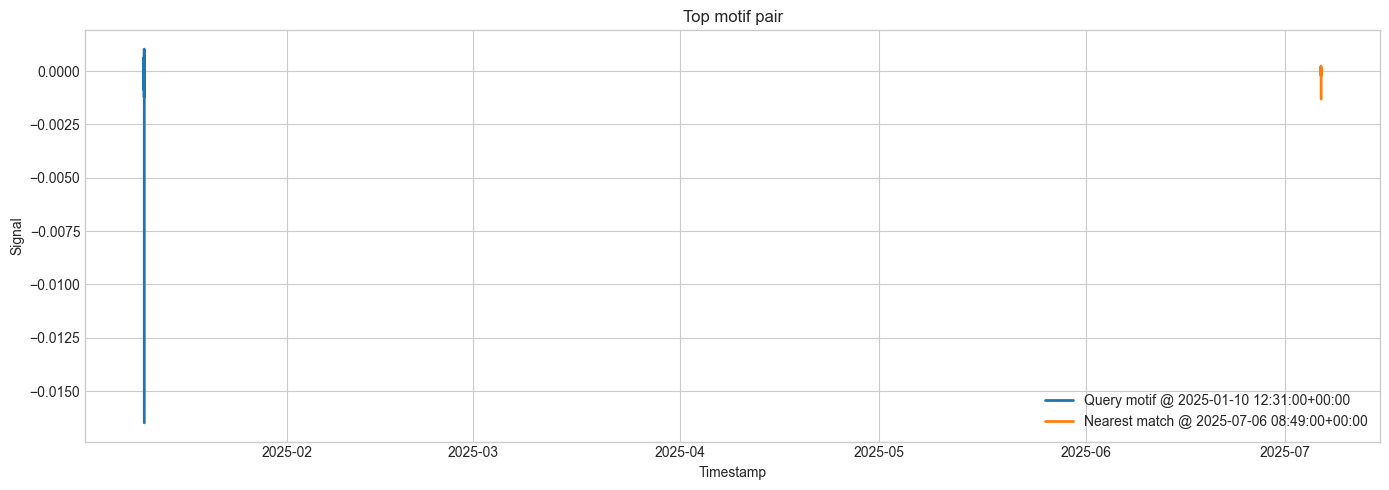

In [13]:
if motif_df.empty:
    print("No motif pair was selected.")
else:
    row = motif_df.iloc[0]
    query_slice = slice(int(row["query_index"]), int(row["query_index"]) + window)
    match_slice = slice(int(row["match_index"]), int(row["match_index"]) + window)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(
        sample_df["timestamp"].iloc[query_slice],
        sample_df["signal"].iloc[query_slice],
        label=f"Query motif @ {row['query_time']}",
        linewidth=2,
    )
    ax.plot(
        sample_df["timestamp"].iloc[match_slice],
        sample_df["signal"].iloc[match_slice],
        label=f"Nearest match @ {row['match_time']}",
        linewidth=2,
    )
    ax.set_title("Top motif pair")
    ax.set_ylabel("Signal")
    ax.set_xlabel("Timestamp")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Notes for further editing

- Change `analysis_year` if you want to profile a different full-year slice.
- Benchmark several `window` values to see which motif duration is most interpretable for BTC returns.
- If you want a direct CPU vs GPU timing comparison, duplicate the compute cell and force one run with `stumpy.stump` and one with `stumpy.gpu_stump`.
- Once the univariate run is stable, you can branch from here into multivariate motif experiments.

# Build motif and discord tables with timestamps


In [14]:
# Build motif and discord summaries with timestamps

import numpy as np
import pandas as pd

top_k_motifs = 15
top_k_discords = 15
exclusion_zone = window // 2

matrix_profile = np.asarray(mp[:, 0], dtype=np.float64)
nearest_neighbor_idx = np.asarray(mp[:, 1], dtype=np.int64)

valid_mask = np.isfinite(matrix_profile)
valid_indices = np.where(valid_mask)[0]

print(f"Total subsequences evaluated: {len(matrix_profile):,}")
print(f"Finite matrix profile values: {valid_mask.sum():,}")
print(f"Invalid / inf values: {(~valid_mask).sum():,}")

# ---------- Motifs ----------
motif_rows = []
used = np.zeros(len(matrix_profile), dtype=bool)

for idx in np.argsort(matrix_profile):
    if not np.isfinite(matrix_profile[idx]):
        continue

    nn_idx = int(nearest_neighbor_idx[idx])
    if nn_idx < 0 or nn_idx == idx:
        continue

    # avoid heavy overlap between already selected motif windows
    left = max(0, idx - exclusion_zone)
    right = min(len(used), idx + exclusion_zone + 1)
    left_nn = max(0, nn_idx - exclusion_zone)
    right_nn = min(len(used), nn_idx + exclusion_zone + 1)

    if used[left:right].any() or used[left_nn:right_nn].any():
        continue

    motif_rows.append({
        "rank": len(motif_rows) + 1,
        "query_index": int(idx),
        "match_index": int(nn_idx),
        "profile_value": float(matrix_profile[idx]),
        "query_time": sample_df.iloc[idx]["timestamp"],
        "match_time": sample_df.iloc[nn_idx]["timestamp"],
        "query_end_time": sample_df.iloc[min(idx + window - 1, len(sample_df) - 1)]["timestamp"],
        "match_end_time": sample_df.iloc[min(nn_idx + window - 1, len(sample_df) - 1)]["timestamp"],
    })

    used[left:right] = True
    used[left_nn:right_nn] = True

    if len(motif_rows) >= top_k_motifs:
        break

motif_df = pd.DataFrame(motif_rows)

# ---------- Discords ----------
discord_rows = []
used_discord = np.zeros(len(matrix_profile), dtype=bool)

for idx in np.argsort(-matrix_profile):
    if not np.isfinite(matrix_profile[idx]):
        continue

    left = max(0, idx - exclusion_zone)
    right = min(len(used_discord), idx + exclusion_zone + 1)

    if used_discord[left:right].any():
        continue

    discord_rows.append({
        "rank": len(discord_rows) + 1,
        "index": int(idx),
        "profile_value": float(matrix_profile[idx]),
        "timestamp": sample_df.iloc[idx]["timestamp"],
        "end_time": sample_df.iloc[min(idx + window - 1, len(sample_df) - 1)]["timestamp"],
    })

    used_discord[left:right] = True

    if len(discord_rows) >= top_k_discords:
        break

discord_df = pd.DataFrame(discord_rows)

print(f"\nTop motifs found: {len(motif_df)}")
print(f"Top discords found: {len(discord_df)}")

Total subsequences evaluated: 525,541
Finite matrix profile values: 525,541
Invalid / inf values: 0

Top motifs found: 15
Top discords found: 15


## Print motif dates cleanly

In [15]:
# Print motif summary with dates

if motif_df.empty:
    print("No motifs found.")
else:
    print("TOP MOTIFS")
    print("=" * 120)
    for _, row in motif_df.iterrows():
        print(
            f"Rank {int(row['rank'])}: "
            f"Motif [{row['query_time']} -> {row['query_end_time']}] "
            f"(idx {int(row['query_index'])}:{int(row['query_index']) + window}) | "
            f"Neighbor [{row['match_time']} -> {row['match_end_time']}] "
            f"(idx {int(row['match_index'])}:{int(row['match_index']) + window}) | "
            f"MP={row['profile_value']:.6f}"
        )

motif_df

TOP MOTIFS
Rank 1: Motif [2025-01-10 12:31:00+00:00 -> 2025-01-10 13:30:00+00:00] (idx 13711:13771) | Neighbor [2025-07-06 08:49:00+00:00 -> 2025-07-06 09:48:00+00:00] (idx 268369:268429) | MP=2.653183
Rank 2: Motif [2025-09-22 05:03:00+00:00 -> 2025-09-22 06:02:00+00:00] (idx 380463:380523) | Neighbor [2025-08-24 18:38:00+00:00 -> 2025-08-24 19:37:00+00:00] (idx 339518:339578) | MP=2.931639
Rank 3: Motif [2025-08-29 11:31:00+00:00 -> 2025-08-29 12:30:00+00:00] (idx 346291:346351) | Neighbor [2025-01-14 12:31:00+00:00 -> 2025-01-14 13:30:00+00:00] (idx 19471:19531) | MP=3.324551
Rank 4: Motif [2025-10-22 10:04:00+00:00 -> 2025-10-22 11:03:00+00:00] (idx 423964:424024) | Neighbor [2025-11-21 06:34:00+00:00 -> 2025-11-21 07:33:00+00:00] (idx 466954:467014) | MP=3.373826
Rank 5: Motif [2025-10-26 21:04:00+00:00 -> 2025-10-26 22:03:00+00:00] (idx 430384:430444) | Neighbor [2025-07-10 20:18:00+00:00 -> 2025-07-10 21:17:00+00:00] (idx 274818:274878) | MP=3.378580
Rank 6: Motif [2025-01-09 01

,rank,query_index,match_index,profile_value,query_time,match_time,query_end_time,match_end_time
0,1,13711,268369,2.653183,2025-01-10 12:31:00+00:00,2025-07-06 08:49:00+00:00,2025-01-10 13:30:00+00:00,2025-07-06 09:48:00+00:00
1,2,380463,339518,2.931639,2025-09-22 05:03:00+00:00,2025-08-24 18:38:00+00:00,2025-09-22 06:02:00+00:00,2025-08-24 19:37:00+00:00
2,3,346291,19471,3.324551,2025-08-29 11:31:00+00:00,2025-01-14 12:31:00+00:00,2025-08-29 12:30:00+00:00,2025-01-14 13:30:00+00:00
3,4,423964,466954,3.373826,2025-10-22 10:04:00+00:00,2025-11-21 06:34:00+00:00,2025-10-22 11:03:00+00:00,2025-11-21 07:33:00+00:00
4,5,430384,274818,3.378580,2025-10-26 21:04:00+00:00,2025-07-10 20:18:00+00:00,2025-10-26 22:03:00+00:00,2025-07-10 21:17:00+00:00
5,6,11591,399394,3.680803,2025-01-09 01:11:00+00:00,2025-10-05 08:34:00+00:00,2025-01-09 02:10:00+00:00,2025-10-05 09:33:00+00:00
6,7,423271,356956,3.857683,2025-10-21 22:31:00+00:00,2025-09-05 21:16:00+00:00,2025-10-21 23:30:00+00:00,2025-09-05 22:15:00+00:00
7,8,247465,343882,3.930583,2025-06-21 20:25:00+00:00,2025-08-27 19:22:00+00:00,2025-06-21 21:24:00+00:00,2025-08-27 20:21:00+00:00
8,9,269072,258185,3.954404,2025-07-06 20:32:00+00:00,2025-06-29 07:05:00+00:00,2025-07-06 21:31:00+00:00,2025-06-29 08:04:00+00:00
9,10,228648,178389,3.997043,2025-06-08 18:48:00+00:00,2025-05-04 21:09:00+00:00,2025-06-08 19:47:00+00:00,2025-05-04 22:08:00+00:00


## Print discord dates cleanly

In [16]:
# Print discord summary with dates

if discord_df.empty:
    print("No discords found.")
else:
    print("TOP DISCORDS")
    print("=" * 120)
    for _, row in discord_df.iterrows():
        print(
            f"Rank {int(row['rank'])}: "
            f"Discord [{row['timestamp']} -> {row['end_time']}] "
            f"(idx {int(row['index'])}:{int(row['index']) + window}) | "
            f"MP={row['profile_value']:.6f}"
        )

discord_df

TOP DISCORDS
Rank 1: Discord [2025-07-18 07:17:00+00:00 -> 2025-07-18 08:16:00+00:00] (idx 285557:285617) | MP=7.756587
Rank 2: Discord [2025-01-09 13:56:00+00:00 -> 2025-01-09 14:55:00+00:00] (idx 12356:12416) | MP=7.742789
Rank 3: Discord [2025-03-05 09:00:00+00:00 -> 2025-03-05 09:59:00+00:00] (idx 91260:91320) | MP=7.733290
Rank 4: Discord [2025-03-09 18:44:00+00:00 -> 2025-03-09 19:43:00+00:00] (idx 97604:97664) | MP=7.730010
Rank 5: Discord [2025-12-18 08:03:00+00:00 -> 2025-12-18 09:02:00+00:00] (idx 505923:505983) | MP=7.728219
Rank 6: Discord [2025-04-05 17:04:00+00:00 -> 2025-04-05 18:03:00+00:00] (idx 136384:136444) | MP=7.727313
Rank 7: Discord [2025-05-16 05:26:00+00:00 -> 2025-05-16 06:25:00+00:00] (idx 194726:194786) | MP=7.721938
Rank 8: Discord [2025-09-25 15:13:00+00:00 -> 2025-09-25 16:12:00+00:00] (idx 385393:385453) | MP=7.719345
Rank 9: Discord [2025-06-20 00:43:00+00:00 -> 2025-06-20 01:42:00+00:00] (idx 244843:244903) | MP=7.719074
Rank 10: Discord [2025-03-13 1

,rank,index,profile_value,timestamp,end_time
0,1,285557,7.756587,2025-07-18 07:17:00+00:00,2025-07-18 08:16:00+00:00
1,2,12356,7.742789,2025-01-09 13:56:00+00:00,2025-01-09 14:55:00+00:00
2,3,91260,7.733290,2025-03-05 09:00:00+00:00,2025-03-05 09:59:00+00:00
3,4,97604,7.730010,2025-03-09 18:44:00+00:00,2025-03-09 19:43:00+00:00
4,5,505923,7.728219,2025-12-18 08:03:00+00:00,2025-12-18 09:02:00+00:00
5,6,136384,7.727313,2025-04-05 17:04:00+00:00,2025-04-05 18:03:00+00:00
6,7,194726,7.721938,2025-05-16 05:26:00+00:00,2025-05-16 06:25:00+00:00
7,8,385393,7.719345,2025-09-25 15:13:00+00:00,2025-09-25 16:12:00+00:00
8,9,244843,7.719074,2025-06-20 00:43:00+00:00,2025-06-20 01:42:00+00:00
9,10,103046,7.711534,2025-03-13 13:26:00+00:00,2025-03-13 14:25:00+00:00


## Plot the matrix profile and mark motifs + discords

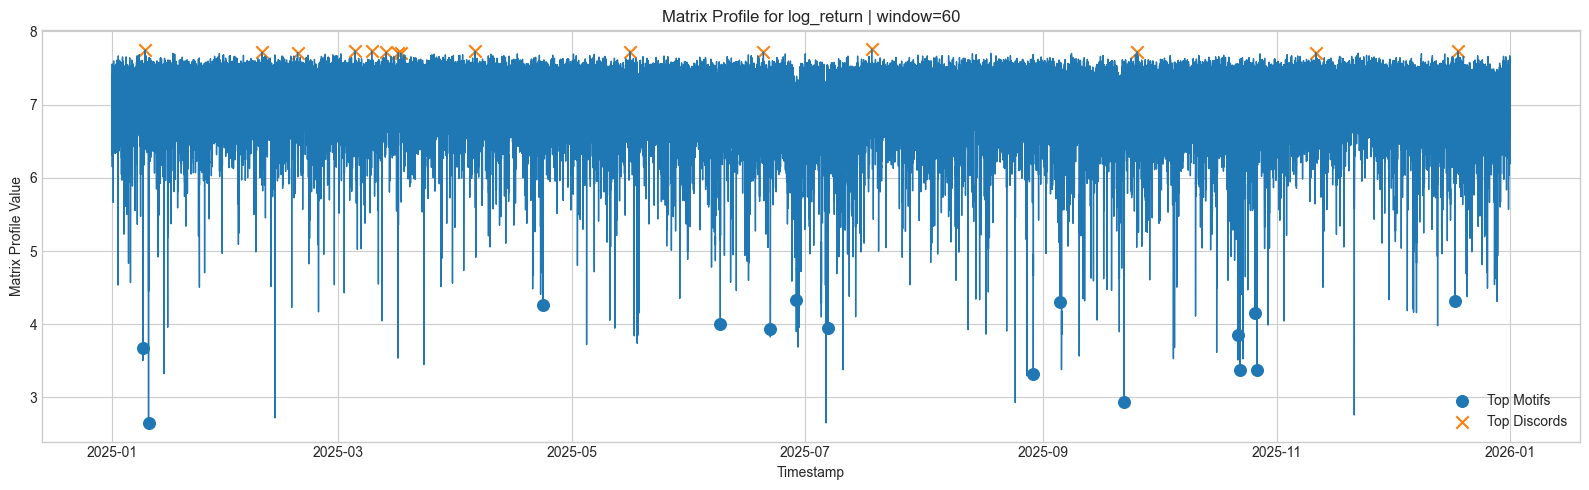

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(sample_df["timestamp"].iloc[:len(matrix_profile)], matrix_profile, linewidth=1.0)
ax.set_title(f"Matrix Profile for {candidate_column} | window={window}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Matrix Profile Value")

if not motif_df.empty:
    ax.scatter(
        motif_df["query_time"],
        motif_df["profile_value"],
        s=70,
        marker="o",
        label="Top Motifs"
    )

if not discord_df.empty:
    ax.scatter(
        discord_df["timestamp"],
        discord_df["profile_value"],
        s=80,
        marker="x",
        label="Top Discords"
    )

ax.legend()
plt.tight_layout()
plt.show()

In [18]:
%pip install mplfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Side-by-side matrix profile + candlestick for a chosen motif

This cell plots:

left: matrix profile with highlighted motif windows

right: candlestick chart for the two matching subsequences

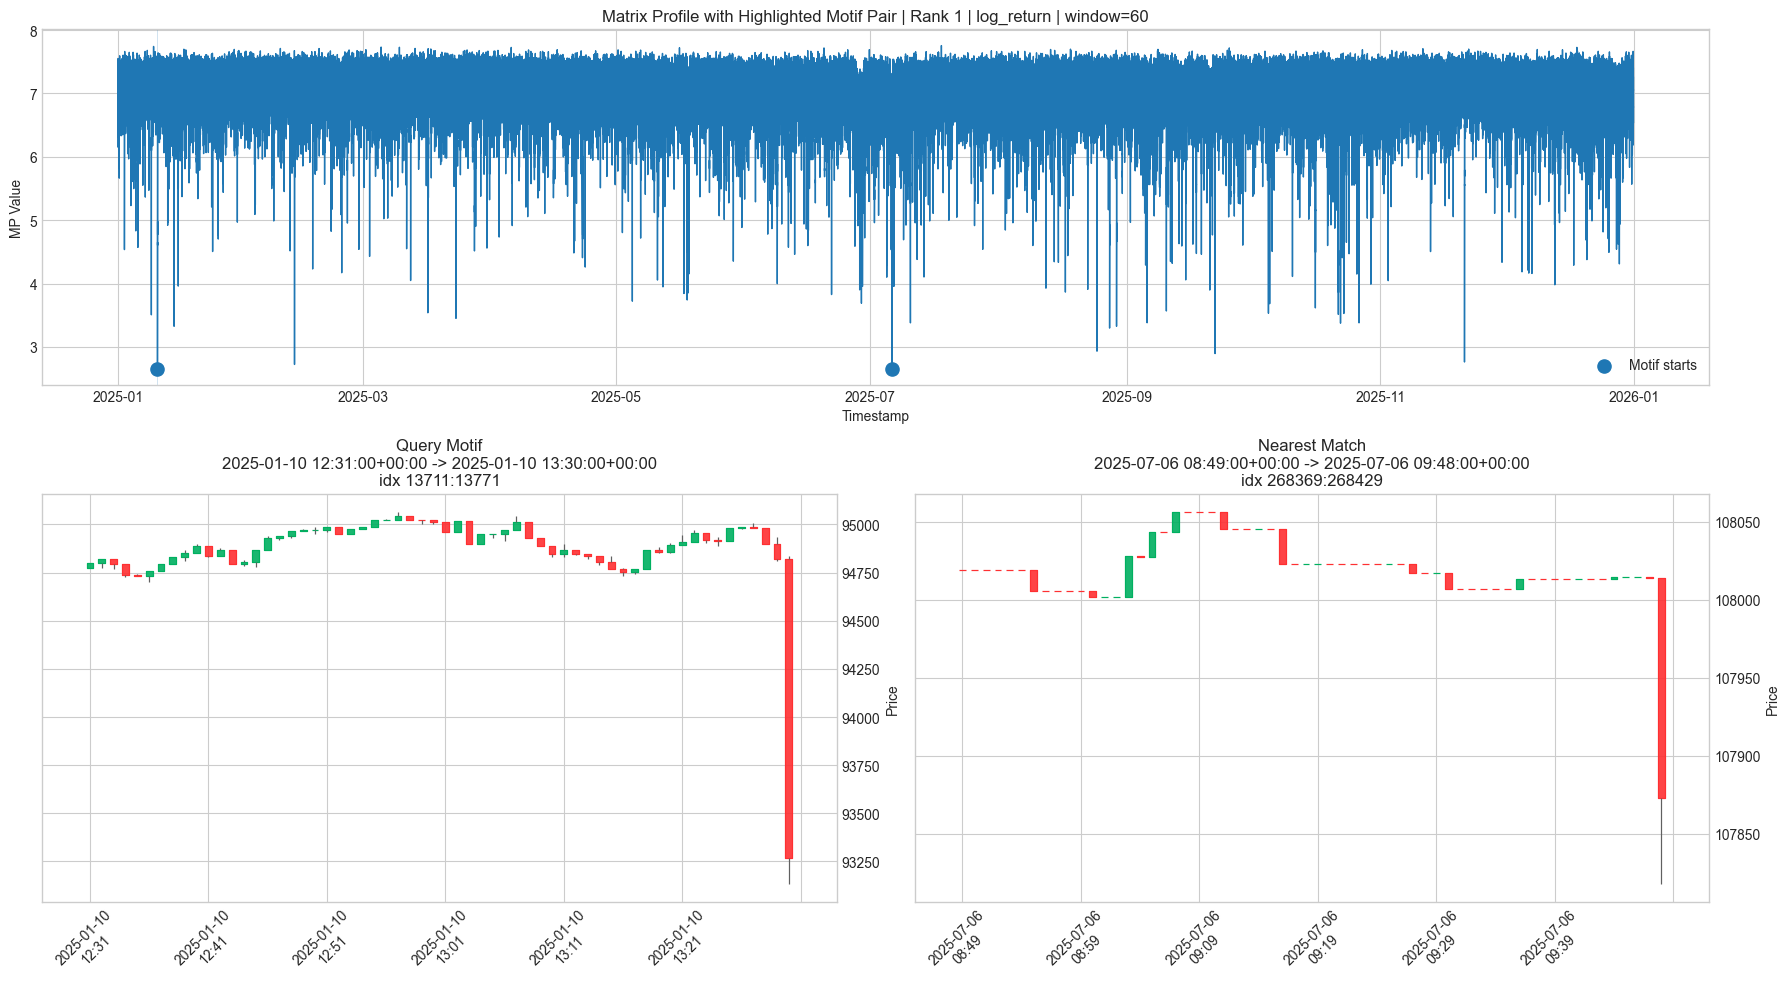

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import mplfinance as mpf

motif_rank_to_plot = 1  # change this: 1, 2, 3, ...

if motif_df.empty:
    print("No motifs available to plot.")
else:
    row = motif_df.iloc[motif_rank_to_plot - 1]

    q_idx = int(row["query_index"])
    m_idx = int(row["match_index"])

    query_slice = slice(q_idx, q_idx + window)
    match_slice = slice(m_idx, m_idx + window)

    # matrix profile series
    mp_time = sample_df["timestamp"].iloc[:len(matrix_profile)]
    mp_vals = matrix_profile

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

    # ---------- Top: matrix profile ----------
    ax_mp = fig.add_subplot(gs[0, :])
    ax_mp.plot(mp_time, mp_vals, linewidth=1.0)
    ax_mp.set_title(
        f"Matrix Profile with Highlighted Motif Pair | Rank {motif_rank_to_plot} | "
        f"{candidate_column} | window={window}"
    )
    ax_mp.set_xlabel("Timestamp")
    ax_mp.set_ylabel("MP Value")

    # highlight motif start points
    ax_mp.scatter(
        [sample_df.iloc[q_idx]["timestamp"], sample_df.iloc[m_idx]["timestamp"]],
        [matrix_profile[q_idx], matrix_profile[m_idx]],
        s=90,
        marker="o",
        label="Motif starts"
    )

    # highlight full subsequence spans
    q_start = sample_df.iloc[q_idx]["timestamp"]
    q_end = sample_df.iloc[min(q_idx + window - 1, len(sample_df) - 1)]["timestamp"]
    m_start = sample_df.iloc[m_idx]["timestamp"]
    m_end = sample_df.iloc[min(m_idx + window - 1, len(sample_df) - 1)]["timestamp"]

    ax_mp.axvspan(q_start, q_end, alpha=0.20)
    ax_mp.axvspan(m_start, m_end, alpha=0.20)
    ax_mp.legend()

    # ---------- Bottom-left: query candlestick ----------
    query_ohlc = sample_df.iloc[query_slice][["timestamp", "open", "high", "low", "close", "volume"]].copy()
    query_ohlc = query_ohlc.set_index("timestamp")

    ax_q = fig.add_subplot(gs[1, 0])
    mpf.plot(
        query_ohlc,
        type="candle",
        volume=False,
        ax=ax_q,
        style="yahoo",
        datetime_format="%Y-%m-%d\n%H:%M"
    )
    ax_q.set_title(
        f"Query Motif\n{row['query_time']} -> {row['query_end_time']}\n"
        f"idx {q_idx}:{q_idx + window}"
    )

    # ---------- Bottom-right: match candlestick ----------
    match_ohlc = sample_df.iloc[match_slice][["timestamp", "open", "high", "low", "close", "volume"]].copy()
    match_ohlc = match_ohlc.set_index("timestamp")

    ax_m = fig.add_subplot(gs[1, 1])
    mpf.plot(
        match_ohlc,
        type="candle",
        volume=False,
        ax=ax_m,
        style="yahoo",
        datetime_format="%Y-%m-%d\n%H:%M"
    )
    ax_m.set_title(
        f"Nearest Match\n{row['match_time']} -> {row['match_end_time']}\n"
        f"idx {m_idx}:{m_idx + window}"
    )

    plt.tight_layout()
    plt.show()

## Shape comparison plot for the same motif pair

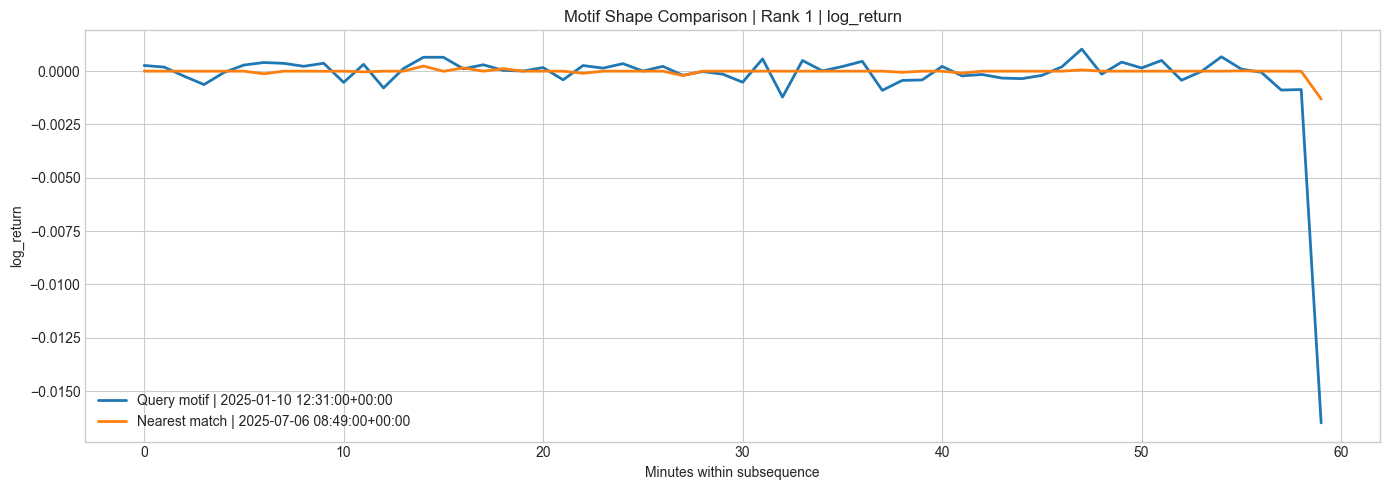

In [20]:
motif_rank_to_plot = 1  # change as needed

if motif_df.empty:
    print("No motifs available to compare.")
else:
    row = motif_df.iloc[motif_rank_to_plot - 1]

    q_idx = int(row["query_index"])
    m_idx = int(row["match_index"])

    q_signal = sample_df["signal"].iloc[q_idx:q_idx + window].to_numpy()
    m_signal = sample_df["signal"].iloc[m_idx:m_idx + window].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(q_signal, linewidth=2, label=f"Query motif | {row['query_time']}")
    ax.plot(m_signal, linewidth=2, label=f"Nearest match | {row['match_time']}")
    ax.set_title(f"Motif Shape Comparison | Rank {motif_rank_to_plot} | {candidate_column}")
    ax.set_xlabel("Minutes within subsequence")
    ax.set_ylabel(candidate_column)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Same side-by-side plot but for a discord window

Discords do not have a paired neighbor in the same interpretation sense, so here we show:

top: matrix profile with discord highlighted
bottom: candlestick chart of that anomalous subsequence

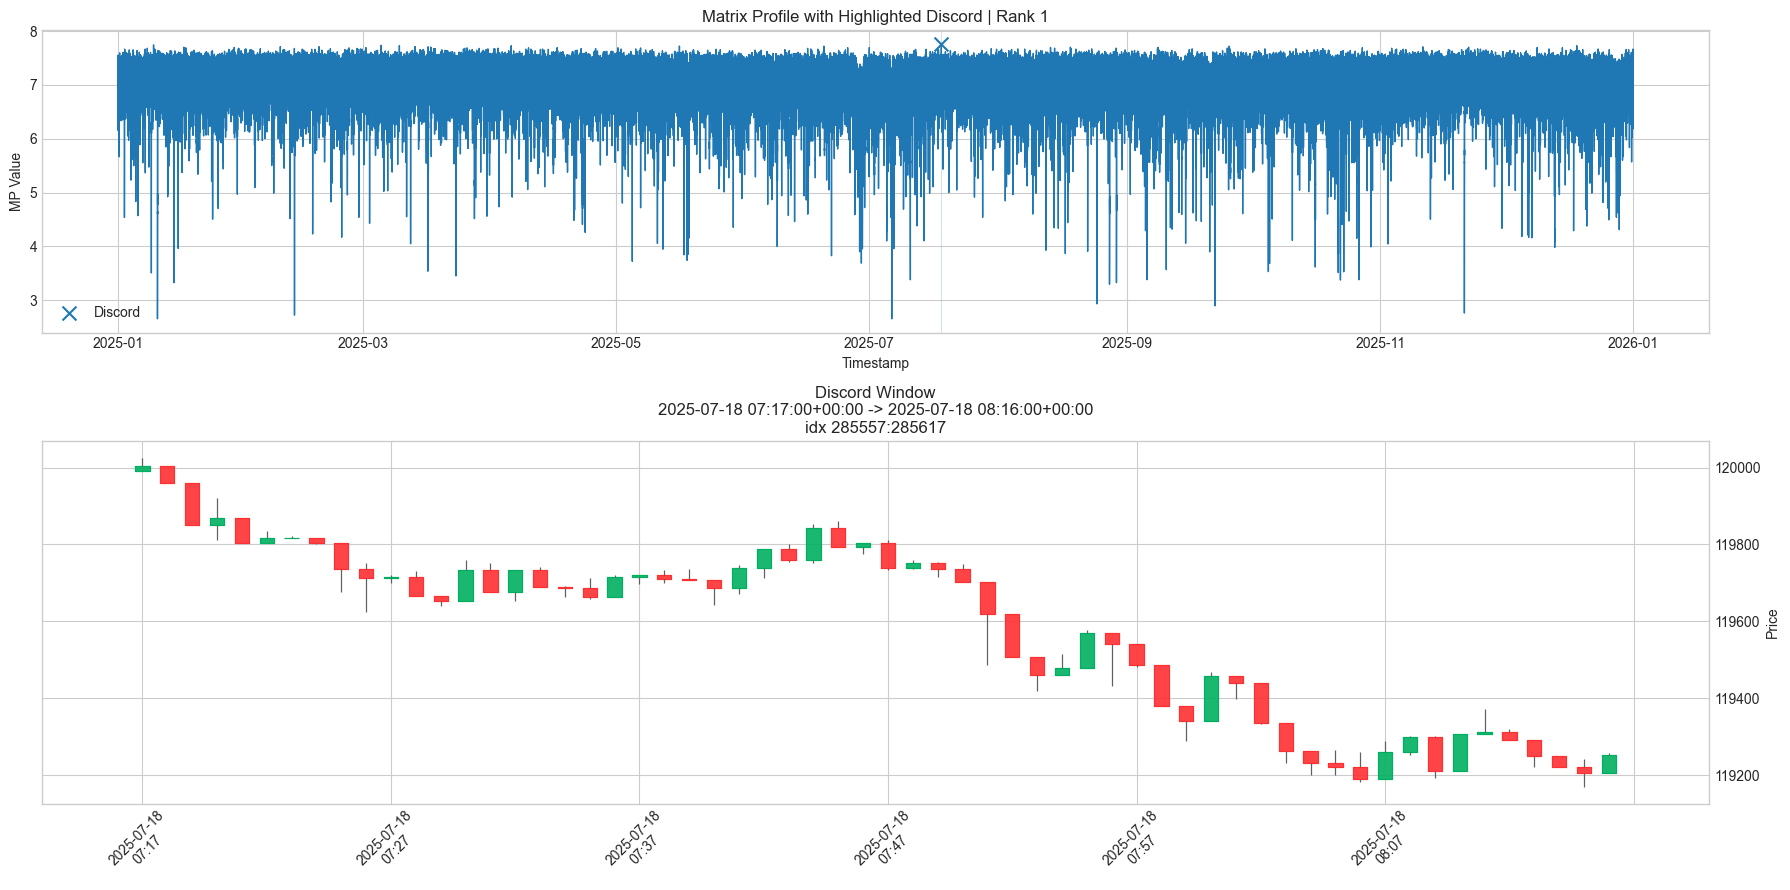

In [21]:
discord_rank_to_plot = 1  # change this

if discord_df.empty:
    print("No discords available to plot.")
else:
    row = discord_df.iloc[discord_rank_to_plot - 1]
    d_idx = int(row["index"])
    discord_slice = slice(d_idx, d_idx + window)

    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

    # top: matrix profile
    ax_mp = fig.add_subplot(gs[0, 0])
    ax_mp.plot(sample_df["timestamp"].iloc[:len(matrix_profile)], matrix_profile, linewidth=1.0)
    ax_mp.scatter(row["timestamp"], row["profile_value"], s=100, marker="x", label="Discord")
    ax_mp.axvspan(row["timestamp"], row["end_time"], alpha=0.20)
    ax_mp.set_title(f"Matrix Profile with Highlighted Discord | Rank {discord_rank_to_plot}")
    ax_mp.set_xlabel("Timestamp")
    ax_mp.set_ylabel("MP Value")
    ax_mp.legend()

    # bottom: discord candlestick
    discord_ohlc = sample_df.iloc[discord_slice][["timestamp", "open", "high", "low", "close", "volume"]].copy()
    discord_ohlc = discord_ohlc.set_index("timestamp")

    ax_d = fig.add_subplot(gs[1, 0])
    mpf.plot(
        discord_ohlc,
        type="candle",
        volume=False,
        ax=ax_d,
        style="yahoo",
        datetime_format="%Y-%m-%d\n%H:%M"
    )
    ax_d.set_title(
        f"Discord Window\n{row['timestamp']} -> {row['end_time']}\n"
        f"idx {d_idx}:{d_idx + window}"
    )

    plt.tight_layout()
    plt.show()